In [1]:
import requests
import os

In [2]:
#url = "http://www.gutenberg.org/files/2600/2600-0.txt"
url = "https://archive.org/stream/CarlGustavJungTheRedBookLiberNovusenglish.ocrNo.images/Carl%20Gustav%20Jung%20-%20The%20Red%20Book%20-%20Liber%20Novus%20%5Benglish.ocr_no.images%5D_djvu.txt"

html = requests.get(url).content.decode()

In [3]:
from bs4 import BeautifulSoup

In [4]:
soup = BeautifulSoup(html, "html")

In [5]:
text = soup.get_text()

In [6]:
text[:500]

'\n\n\nFull text of "Carl Gustav Jung The Red Book Liber Novus [english.ocr No.images]"\n\n\n\n\n\n\n\n\n\n\n \n\n\n\n\n\n\nSkip to main content\n\n\n\n\nAsk the publishers to restore access to 500,000+ books.\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nHamburger icon\nAn icon used to represent a menu that can be toggled by interacting with this icon.\n\n\n\n\n\n\n\nInternet Archive logo\nA line drawing of the Internet Archive headquarters building façade.\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nWeb icon\nAn illustration of a computer application window\n\n\n\nWayback '

In [7]:
text[:500].lower()

'\n\n\nfull text of "carl gustav jung the red book liber novus [english.ocr no.images]"\n\n\n\n\n\n\n\n\n\n\n \n\n\n\n\n\n\nskip to main content\n\n\n\n\nask the publishers to restore access to 500,000+ books.\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nhamburger icon\nan icon used to represent a menu that can be toggled by interacting with this icon.\n\n\n\n\n\n\n\ninternet archive logo\na line drawing of the internet archive headquarters building façade.\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nweb icon\nan illustration of a computer application window\n\n\n\nwayback '

# Text Indexing

In [8]:
from nltk import sent_tokenize

sentences = sent_tokenize(text.lower())

In [9]:
len(sentences)

13429

In [10]:
from nltk import word_tokenize

# expected input for distr models like word2vec
tok_sents = [word_tokenize(sentence) for sentence in sentences]

In [11]:
tok_sents[-1]

['you',
 'should',
 'call',
 'me',
 'if',
 'you',
 'want',
 'to',
 'live',
 'with',
 'men',
 ',',
 'but',
 'the',
 'one',
 'god',
 'if',
 'you',
 'want',
 'to',
 'rise',
 'above',
 'the',
 'human',
 'world',
 'to',
 'the',
 'divine',
 'and',
 'eternal',
 'solitude',
 'of',
 'the',
 'star',
 '.']

In [12]:
tokens = word_tokenize(text.lower())

vocab = set(tokens)

In [13]:
len(tokens)

272610

In [14]:
len(vocab)

17255

In [15]:
len(vocab) / len(tokens)

0.06329555042001393

In [16]:
#tokens = [token for token in tokens if len(token) > 3] # characters shorten than 3

In [17]:
from nltk.corpus import stopwords
import string

en_stop = set(stopwords.words('english'))
punctuations = list(set(string.punctuation)) + ["``", "''", "“", "“", "”", "’"]
punctuations = set(punctuations)

tokens = [token for token in tokens if token not in en_stop and token not in punctuations]

In [18]:
punctuations

{'!',
 '"',
 '#',
 '$',
 '%',
 '&',
 "'",
 "''",
 '(',
 ')',
 '*',
 '+',
 ',',
 '-',
 '.',
 '/',
 ':',
 ';',
 '<',
 '=',
 '>',
 '?',
 '@',
 '[',
 '\\',
 ']',
 '^',
 '_',
 '`',
 '``',
 '{',
 '|',
 '}',
 '~',
 '’',
 '“',
 '”'}

In [19]:
from nltk.stem.wordnet import WordNetLemmatizer

# Function to lemmatize
def get_lemma(token):
    return WordNetLemmatizer().lemmatize(token)

tokens = [get_lemma(token) for token in tokens] 

In [20]:
from collections import Counter

frequencies = list(Counter(tokens).items())
frequencies[:30]

[('full', 79),
 ('text', 73),
 ('carl', 6),
 ('gustav', 8),
 ('jung', 954),
 ('red', 113),
 ('book', 389),
 ('liber', 256),
 ('novus', 167),
 ('english.ocr', 2),
 ('no.images', 2),
 ('skip', 1),
 ('main', 19),
 ('content', 46),
 ('ask', 46),
 ('publisher', 1),
 ('restore', 8),
 ('access', 8),
 ('500,000+', 1),
 ('hamburger', 1),
 ('icon', 19),
 ('used', 37),
 ('represent', 15),
 ('menu', 1),
 ('toggled', 1),
 ('interacting', 1),
 ('internet', 5),
 ('archive', 21),
 ('logo', 49),
 ('line', 50)]

In [21]:
frequencies.sort(key=lambda x: x[1], reverse=True)

In [22]:
for word, frequency in frequencies[:30]:
    print(word,'\t',frequency)

one 	 1173
god 	 996
jung 	 954
life 	 617
p. 	 583
see 	 533
soul 	 522
since 	 505
also 	 479
man 	 471
like 	 434
would 	 420
know 	 418
want 	 417
time 	 408
way 	 396
book 	 389
come 	 380
love 	 370
world 	 365
must 	 362
image 	 335
men 	 327
work 	 310
could 	 305
thing 	 303
black 	 299
become 	 290
word 	 283
said 	 281


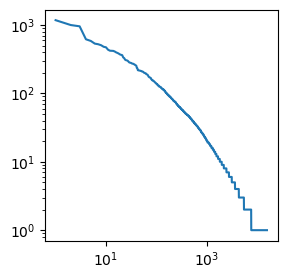

In [23]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
plt.loglog([i+1 for i,_ in enumerate(frequencies)],[f for w,f in frequencies])

plt.show()

In [24]:
from gensim.models.phrases import Phraser, Phrases

In [25]:
Phrases([tokens]).vocab

{'full': 79,
 'text': 73,
 'full_text': 2,
 'carl': 6,
 'text_carl': 2,
 'gustav': 8,
 'carl_gustav': 4,
 'jung': 954,
 'gustav_jung': 4,
 'red': 113,
 'jung_red': 3,
 'book': 389,
 'red_book': 34,
 'liber': 256,
 'book_liber': 8,
 'novus': 167,
 'liber_novus': 163,
 'english.ocr': 2,
 'novus_english.ocr': 2,
 'no.images': 2,
 'english.ocr_no.images': 2,
 'skip': 1,
 'no.images_skip': 1,
 'main': 19,
 'skip_main': 1,
 'content': 46,
 'main_content': 1,
 'ask': 46,
 'content_ask': 1,
 'publisher': 1,
 'ask_publisher': 1,
 'restore': 8,
 'publisher_restore': 1,
 'access': 8,
 'restore_access': 1,
 '500,000+': 1,
 'access_500,000+': 1,
 '500,000+_book': 1,
 'hamburger': 1,
 'book_hamburger': 1,
 'icon': 19,
 'hamburger_icon': 1,
 'icon_icon': 1,
 'used': 37,
 'icon_used': 1,
 'represent': 15,
 'used_represent': 1,
 'menu': 1,
 'represent_menu': 1,
 'toggled': 1,
 'menu_toggled': 1,
 'interacting': 1,
 'toggled_interacting': 1,
 'interacting_icon': 1,
 'internet': 5,
 'icon_internet': 1,
 

In [26]:
bigram = Phraser(Phrases([tokens]))
bigram.phrasegrams

{'red_book': 73.12443979343449,
 'liber_novus': 409.63140905688624,
 'icon_illustration': 2916.815789473684,
 'c._g.': 1535.1662049861495,
 'g._jung': 67.26409577402626,
 'modern_psychology': 84.12827324478178,
 'later_work': 35.31310234966149,
 'university_press': 902.1302256751757,
 'jung_referred': 12.448225516621743,
 'twentieth_century': 395.8535714285714,
 'great_deal': 61.577222222222225,
 'automatic_writing': 1077.601388888889,
 'day_night': 18.731844519555768,
 'jung_wrote': 57.619428678563516,
 'dream_vision': 11.811487638533674,
 'year_later': 50.21587948805074,
 'new_york': 381.0090625,
 'oxford_university': 522.8254716981132,
 'memory_p.': 56.701965032650236,
 'ibid._p.': 51.49038736420812,
 'goethe_faust': 852.6076923076923,
 'middle_age': 304.26392156862744,
 'thus_spoke': 48.300717350496114,
 'spoke_zarathustra': 280.25031605562583,
 'heaven_hell': 75.10265386787125,
 'princeton_princeton': 1216.3401920438957,
 'princeton_university': 697.1006289308176,
 'black_book': 1

# Recap: Text Indexing Pipeline

In [27]:
# Transformation function for each text
def transform(tokens, en_stop, puncts):
    #tokens = tokenize(text)  # Tokenize the text
    tokens = [token.lower() for token in tokens]  # Convert to lowercase
   
    tokens = [token for token in tokens if token not in en_stop and token not in puncts]  # Remove stopwords
    tokens = [get_lemma(token) for token in tokens]  # Lemmatization
    
    return tokens

In [28]:
tok_sents_clean = []
for toks in tok_sents:
    clean_toks = transform(toks, en_stop, punctuations)
    tok_sents_clean.append(clean_toks)

In [29]:
tok_sents_clean[-2]

['body',
 'shadow',
 'effectiveness',
 'world',
 'manifestation',
 'world',
 'god',
 'effulgence',
 'breath',
 'odor',
 'magical',
 'force']

In [30]:
tok_sents[-2]

['i',
 'am',
 'your',
 'body',
 ',',
 'your',
 'shadow',
 ',',
 'your',
 'effectiveness',
 'in',
 'this',
 'world',
 ',',
 'your',
 'manifestation',
 'in',
 'the',
 'world',
 'of',
 'the',
 'gods',
 ',',
 'your',
 'effulgence',
 ',',
 'your',
 'breath',
 ',',
 'your',
 'odor',
 ',',
 'your',
 'magical',
 'force',
 '.']

In [31]:
# WORD-CONTEXT

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
import pandas as pd

ex1 = " ".join(tok_sents_clean[-3])
ex2 = " ".join(tok_sents_clean[-2])
ex3 = " ".join(tok_sents_clean[-1])

print(ex1)
print(ex2)
print(ex3)

vectorizer = CountVectorizer()
X = vectorizer.fit_transform([ex1, ex2, ex3])

word_context_matrix = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

stand abraxas all-encompassing
body shadow effectiveness world manifestation world god effulgence breath odor magical force
call want live men one god want rise human world divine eternal solitude star


In [32]:
word_context_matrix

,abraxas,all,body,breath,call,divine,effectiveness,effulgence,encompassing,eternal,...,men,odor,one,rise,shadow,solitude,stand,star,want,world
0,1,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
1,0,0,1,1,0,0,1,1,0,0,...,0,1,0,0,1,0,0,0,0,2
2,0,0,0,0,1,1,0,0,0,1,...,1,0,1,1,0,1,0,1,2,1


In [33]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
import pandas as pd

ex1 = " ".join(tok_sents_clean[-3])  
ex2 = " ".join(tok_sents_clean[-2])
ex3 = " ".join(tok_sents_clean[-1])

print(ex1)
print(ex2)
print(ex3)

vectorizer = CountVectorizer()
X = vectorizer.fit_transform([ex1, ex2, ex3])

tfidf_transformer = TfidfTransformer()

X_tfidf = tfidf_transformer.fit_transform(X)

word_context_matrix = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer.get_feature_names_out())

stand abraxas all-encompassing
body shadow effectiveness world manifestation world god effulgence breath odor magical force
call want live men one god want rise human world divine eternal solitude star


In [34]:
word_context_matrix

,abraxas,all,body,breath,call,divine,effectiveness,effulgence,encompassing,eternal,...,men,odor,one,rise,shadow,solitude,stand,star,want,world
0,0.5,0.5,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.5,0.00000,...,0.00000,0.000000,0.00000,0.00000,0.000000,0.00000,0.5,0.00000,0.00000,0.000000
1,0.0,0.0,0.289983,0.289983,0.00000,0.00000,0.289983,0.289983,0.0,0.00000,...,0.00000,0.289983,0.00000,0.00000,0.289983,0.00000,0.0,0.00000,0.00000,0.441079
2,0.0,0.0,0.000000,0.000000,0.25686,0.25686,0.000000,0.000000,0.0,0.25686,...,0.25686,0.000000,0.25686,0.25686,0.000000,0.25686,0.0,0.25686,0.51372,0.195349


<b> CountVectorizer / TfidfVectorizer </b> are useful for generating sparse representations of documents based on word counts or TF-IDF scores. However, they don’t capture semantic relationships between words.

<b> Word2Vec </b> generates dense word embeddings that capture deeper semantic relationships between words based on their contexts. It essentially learns an embedding space where semantically similar words are placed closer to each other.

# Dense Vector Representations, Example: word2vec

Parameters:

sentences (iterable of iterables, optional) – The sentences iterable can be simply a list of lists of tokens, but for larger corpora, consider an iterable that streams the sentences directly from disk/network.

vector_size (int, optional) – Dimensionality of the word vectors.

window (int, optional) – Maximum distance between the current and predicted word within a sentence.

min_count (int, optional) – Ignores all words with total frequency lower than this.

sg ({0, 1}, optional) – Training algorithm: 1 for skip-gram; otherwise CBOW.

epochs (int, optional) – Number of iterations (epochs) over the corpus. (Formerly: iter)

negative (int, optional) – If > 0, negative sampling will be used, the int for negative specifies how many “noise words” should be drawn (usually between 5-20). If set to 0, no negative sampling is used.

In [35]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(tok_sents_clean, vector_size=50, window=5, min_count=5, sg=1, epochs=20, negative=10)

In [36]:
god_vector = w2v_model.wv['god']  # get numpy vector of a word

print(len(god_vector), god_vector) # prints the vector_size parameter and the values in the vector

50 [ 0.18156904 -0.06340982 -0.64327663 -0.22475968 -0.05353055 -0.00864584
  0.39146504  0.47958672  0.19215415 -0.07729606  0.11188982  0.26914352
  0.29718083  0.27300033  0.02166165  0.35276353  0.2919025   0.05191367
 -0.54353815 -0.32955387 -0.21091509  0.72812444  0.72502506 -0.30955508
  0.06121931  0.2957921   0.21811835  0.02209636  0.03326575  0.16669042
  0.36664292  0.1656393  -0.3631944   0.6201629  -0.37256482  0.6673246
  0.32460186 -0.0436505  -0.02603914  0.15962923  0.05205359  0.1671044
 -0.09141079  0.0778951   0.51928556 -0.0580578  -0.4323097  -0.5034349
  0.35666132  0.31664112]


In [37]:
god_sims = w2v_model.wv.most_similar('god', topn=15)  # get other similar words

god_sims

[('conceiving', 0.7677637338638306),
 ('harbor', 0.7409459948539734),
 ('wear', 0.7366930842399597),
 ('mortal', 0.7271595597267151),
 ('engendered', 0.7203800082206726),
 ('woe', 0.7134119272232056),
 ('us', 0.7117127776145935),
 ('mocked', 0.708885133266449),
 ('celestial', 0.7059162855148315),
 ('hospitality', 0.705411970615387),
 ('tidings', 0.7048466205596924),
 ('anointed', 0.7047500014305115),
 ('ill', 0.7029691934585571),
 ('mightiest', 0.7019350528717041),
 ('serf', 0.701385498046875)]

In [38]:
w2v_model.wv.most_similar(['said'])

[('interrupted', 0.6399734616279602),
 ('yesterday', 0.626884400844574),
 ('saddened', 0.600523829460144),
 ('sorceress', 0.5823006629943848),
 ('pulled', 0.5770926475524902),
 ('replied', 0.5745929479598999),
 ('oiahmhn', 0.5726749897003174),
 ('ended', 0.5691497921943665),
 ('recalled', 0.5677289366722107),
 ('drag', 0.5622304677963257)]

In [39]:
w2v_model.wv.vectors[0]

array([ 0.21379663,  0.00151579, -0.07556023,  0.10602522, -0.44763082,
        0.04119212,  0.37212428,  0.37068477, -0.25990906, -0.46169975,
        0.05484567, -0.49700585,  0.51670444,  0.24720171, -0.25479567,
        0.416125  , -0.02143177, -0.03880173, -0.74437207, -0.32385725,
        0.04471482,  0.6674414 ,  0.3385852 , -0.1248671 ,  0.1307005 ,
        0.43962288,  0.23954077, -0.0989425 , -0.24668172, -0.02518585,
        0.07819171,  0.19175126, -0.03941492,  0.28162676, -0.439895  ,
        0.29398352,  0.25791112, -0.3517374 ,  0.05361953, -0.42363396,
        0.17839192, -0.10274383, -0.1946649 ,  0.15446445,  0.25447878,
       -0.5172025 , -0.25618663, -0.13496871,  0.13263565,  0.10335152],
      dtype=float32)

In [40]:
import gensim.downloader

# Show all available models in gensim-data
gensim.downloader.info()['models'].keys()

dict_keys(['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis'])

In [41]:
# Download the "word2vec-google-news-300" embeddings
google_model = gensim.downloader.load('word2vec-google-news-300')

In [42]:
# Use the downloaded vectors as usual:
google_model.most_similar('god', topn=15)

[('gods', 0.7856107950210571),
 ('deity', 0.7325143218040466),
 ('God', 0.6662932634353638),
 ('diety', 0.6607769727706909),
 ('goddess', 0.6518734693527222),
 ('deities', 0.6512715220451355),
 ('lord', 0.6350281834602356),
 ('god_Zeus', 0.6218457221984863),
 ('Almighty', 0.604067325592041),
 ('Gods', 0.6037754416465759),
 ('supreme_deity', 0.6024163365364075),
 ('demi_god', 0.6020725965499878),
 ('divine', 0.5989402532577515),
 ('Deity', 0.5946497321128845),
 ('jesus_christ', 0.5929667949676514)]

# 3. Clustering

In [43]:
import numpy as np

# Get the words and their corresponding vectors
words = list(w2v_model.wv.index_to_key)
word_vectors = np.array([w2v_model.wv[word] for word in words])

In [44]:
word_vectors[0]

array([ 0.21379663,  0.00151579, -0.07556023,  0.10602522, -0.44763082,
        0.04119212,  0.37212428,  0.37068477, -0.25990906, -0.46169975,
        0.05484567, -0.49700585,  0.51670444,  0.24720171, -0.25479567,
        0.416125  , -0.02143177, -0.03880173, -0.74437207, -0.32385725,
        0.04471482,  0.6674414 ,  0.3385852 , -0.1248671 ,  0.1307005 ,
        0.43962288,  0.23954077, -0.0989425 , -0.24668172, -0.02518585,
        0.07819171,  0.19175126, -0.03941492,  0.28162676, -0.439895  ,
        0.29398352,  0.25791112, -0.3517374 ,  0.05361953, -0.42363396,
        0.17839192, -0.10274383, -0.1946649 ,  0.15446445,  0.25447878,
       -0.5172025 , -0.25618663, -0.13496871,  0.13263565,  0.10335152],
      dtype=float32)

In [45]:
from sklearn.cluster import KMeans

# Define the number of clusters (tune as needed)
num_clusters = 3

# Fit K-Means clustering
kmeans = KMeans(n_clusters=num_clusters, n_init=100)
kmeans.fit(word_vectors)

# Assign clusters to words
word_clusters = {word: cluster for word, cluster in zip(words, kmeans.labels_)}

C:\Users\salva\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\salva\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


In [46]:
word_clusters['god']

2

In [47]:
cluster_id = 2  # Example: cluster 2
words_in_cluster = [word for word, cluster in word_clusters.items() if cluster == cluster_id]

words_in_cluster[:40]

['one',
 'god',
 'life',
 'soul',
 'since',
 'also',
 'man',
 'would',
 'know',
 'want',
 'time',
 'way',
 'love',
 'world',
 'must',
 'men',
 'could',
 'thing',
 'become',
 'word',
 'said',
 'spirit',
 'u',
 'everything',
 'therefore',
 'thus',
 'thought',
 'say',
 'yet',
 'good',
 'power',
 'human',
 'even',
 'take',
 'live',
 'need',
 'still',
 'make',
 'nothing',
 'give']

In [48]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Reduce dimensionality to 2D
tsne = TSNE(n_components=2, random_state=42)
reduced_vectors = tsne.fit_transform(word_vectors)

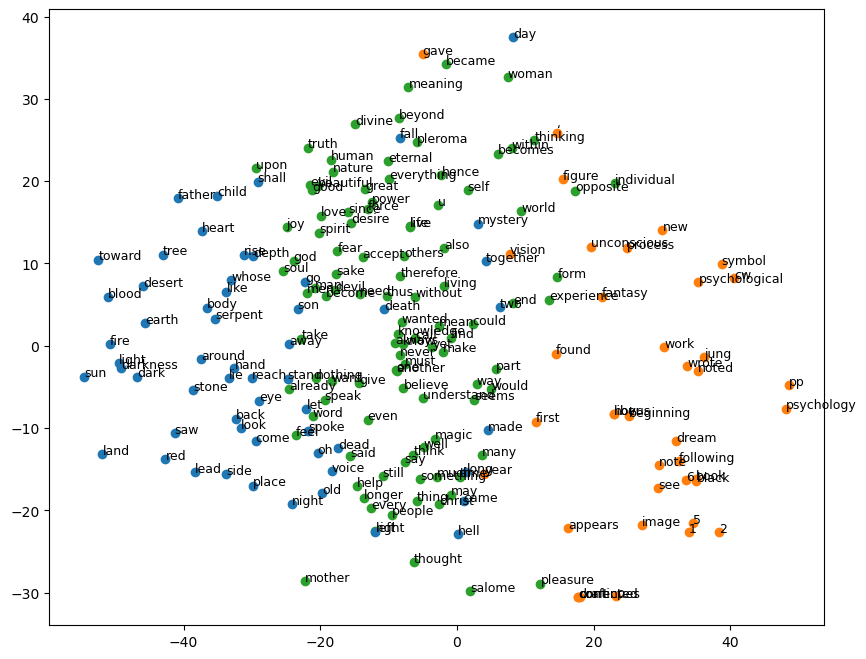

In [49]:
# Plot
plt.figure(figsize=(10, 8))
for i, word in enumerate(words[:200]):
    plt.scatter(reduced_vectors[i, 0], reduced_vectors[i, 1], c=f"C{word_clusters[word]}")
    plt.annotate(word, (reduced_vectors[i, 0], reduced_vectors[i, 1]), fontsize=9)
    
plt.show()